In [1]:
import json
import pandas as pd
import numpy as np
import math
from scipy import stats

from utils.paths import FILES_DIR, CONFIG_DIR, VAL_SETTINGS_FILE
from typing import Any, Dict, List, Optional, Tuple, Union

In [2]:
def load_settings(file_path) -> dict:
    with open(file_path, "r", encoding="utf-8") as f:
        return json.load(f)

def load_csv_like_df(ruta: str, encoding: str = "utf-8", sep: str = ",", dtype=None, parse_dates=None, nrows=None) -> pd.DataFrame:
    try:
        return pd.read_csv(ruta, encoding=encoding, sep=sep, dtype=dtype, parse_dates=parse_dates, nrows=nrows)
    except FileNotFoundError:
        raise
    except Exception as e:
        raise RuntimeError(f"Error al cargar CSV desde `{ruta}`: {e}") from e

def filtrar_simulaciones_validas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filtra el DataFrame para mantener solo las simulaciones (sim_id) que cumplen:
    1. Cantidades exactas en 'conteo_rol' (64 OPCION 4, 46 OPCION 2, 3 VICIADO).
    2. Respeto de los votos pre-etiquetados (OPCION 4 -> OPCION 4, OPCION 2 -> OPCION 2).
    """
    def es_simulacion_valida(grupo):
        # 1. Validación de cantidades totales al final del conteo
        count_op4 = (grupo['conteo_rol'] == 'OPCION 4').sum()
        count_op2 = (grupo['conteo_rol'] == 'OPCION 2').sum()
        count_viciado = (grupo['conteo_rol'] == 'VICIADO').sum()

        cantidades_ok = (count_op4 == 64) and (count_op2 == 46) and (count_viciado == 3)

        # 2. Validación de consistencia para votos que ya sabíamos (pre-etiquetados)
        # Todos los que entraron como OPCION 4 deben haber salido como OPCION 4
        mask_voto_op4 = grupo['vote'] == 'OPCION 4'
        asignacion_op4_ok = (grupo.loc[mask_voto_op4, 'conteo_rol'] == 'OPCION 4').all()

        # Todos los que entraron como OPCION 2 deben haber salido como OPCION 2
        mask_voto_op2 = grupo['vote'] == 'OPCION 2'
        asignacion_op2_ok = (grupo.loc[mask_voto_op2, 'conteo_rol'] == 'OPCION 2').all()

        return cantidades_ok and asignacion_op4_ok and asignacion_op2_ok

    # Agrupamos por simulación y filtramos
    df_filtrado = df.groupby('sim_id').filter(es_simulacion_valida)
    return df_filtrado

def seleccionar_columnas_relevantes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reduce el DataFrame a las columnas estrictamente necesarias para el análisis.
    """
    columnas_deseadas = [
        'sim_id', 'order', 'name', 'name_acronym',
        'party', 'party_acronym', 'vote',
        'conteo_orden', 'conteo_rol'
    ]
    # Retornamos una copia para evitar el warning 'SettingWithCopyWarning' de Pandas
    return df[columnas_deseadas].copy()

In [3]:
def calcular_tc_por_simulacion(df: pd.DataFrame, partido_acronimo: str, rol_esperado: str = 'OPCION 4') -> pd.DataFrame:
    """
    Calcula la Tasa de Coincidencia (Tc) para cada simulación individual.

    Args:
        df: DataFrame ya filtrado (salida de seleccionar_columnas_relevantes).
        partido_acronimo: El acrónimo del partido (ej. 'FP', 'PL', etc.)
        rol_esperado: El valor que esperamos que el simulador le haya asignado en 'conteo_rol'.

    Returns:
        DataFrame con 'sim_id' y su respectivo 'Tc'.
    """
    # 1. Filtramos solo los votos pertenecientes al partido objetivo
    df_partido = df[df['party_acronym'] == partido_acronimo].copy()

    # 2. Creamos una columna booleana que sea True si el modelo acertó (asignó el rol esperado)
    df_partido['acierto'] = df_partido['conteo_rol'] == rol_esperado

    # 3. Agrupamos por simulación y calculamos el promedio de aciertos (eso es exactamente la Tasa de Coincidencia)
    df_tc = df_partido.groupby('sim_id')['acierto'].mean().reset_index()
    df_tc.rename(columns={'acierto': 'Tc'}, inplace=True)

    return df_tc

def estimar_simulaciones_necesarias(df_tc: pd.DataFrame, nivel_confianza: float = 0.95, margen_error: float = 0.02) -> dict:
    """
    Calcula la varianza de la muestra piloto y proyecta el número N de simulaciones necesarias.

    Args:
        df_tc: DataFrame con la columna 'Tc' por cada simulación.
        nivel_confianza: Nivel de confianza estadístico (0.95 es el estándar para 95%).
        margen_error: El error máximo aceptable en la tasa (0.02 significa +/- 2%).

    Returns:
        Diccionario con las estadísticas y el N requerido.
    """
    tc_array = df_tc['Tc'].dropna().values
    n_piloto = len(tc_array)

    if n_piloto < 2:
        raise ValueError("Se necesitan al menos 2 simulaciones válidas para calcular la varianza.")

    # 1. Calcular Media y Desviación Estándar (Muestral, ddof=1)
    media_tc = np.mean(tc_array)
    desviacion_std = np.std(tc_array, ddof=1)

    # 2. Calcular el valor Z para el nivel de confianza (ej. 1.96 para 95%)
    # alfa = 1 - confianza. Z_alfa/2
    z_score = stats.norm.ppf(1 - (1 - nivel_confianza) / 2)

    # 3. Aplicar fórmula del tamaño de muestra: n = (Z * s / E)^2
    n_teorico = ((z_score * desviacion_std) / margen_error) ** 2

    # Siempre redondeamos hacia arriba para asegurar la rigurosidad
    n_requerido = math.ceil(n_teorico)

    return {
        "simulaciones_piloto_usadas": n_piloto,
        "media_tc": media_tc,
        "desviacion_estandar_tc": desviacion_std,
        "margen_error_configurado": margen_error,
        "z_score_usado": z_score,
        "n_total_requerido": n_requerido,
        "simulaciones_faltantes": max(0, n_requerido - n_piloto)
    }

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histograma_tc(df_tc: pd.DataFrame, bins: int = 15):
    """
    Genera un histograma para ver cómo se distribuye la Tasa de Coincidencia (Tc)
    en todas las simulaciones.
    """
    plt.figure(figsize=(10, 6))

    # Histograma con curva de densidad (KDE)
    sns.histplot(data=df_tc, x='Tc', bins=bins, kde=True, color='steelblue', edgecolor='black')

    # Líneas de referencia para la media
    media = df_tc['Tc'].mean()
    plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.4f}')

    plt.title('Distribución de la Tasa de Coincidencia (Tc) por Simulación', fontsize=14)
    plt.xlabel('Tasa de Coincidencia (Tc)', fontsize=12)
    plt.ylabel('Frecuencia (Cantidad de Simulaciones)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

def plot_profundidad_error(df: pd.DataFrame, partido_acronimo: str, rol_esperado: str = 'OPCION 4'):
    """
    Analiza la tasa de éxito en función del orden de extracción (conteo_orden).
    Permite ver si el modelo falla más en los votos de la superficie o en el fondo.
    """
    # Filtramos por partido
    df_partido = df[df['party_acronym'] == partido_acronimo].copy()

    # Determinamos si el motor acertó en la asignación
    df_partido['acierto'] = df_partido['conteo_rol'] == rol_esperado

    # Agrupamos por el orden de conteo real para ver la tasa de éxito en esa capa específica
    # Utilizamos 'conteo_orden' que viene de la extracción
    df_profundidad = df_partido.groupby('conteo_orden')['acierto'].mean().reset_index()
    df_profundidad.rename(columns={'acierto': 'tasa_exito'}, inplace=True)

    plt.figure(figsize=(14, 6))

    # Gráfico de barras o líneas
    sns.barplot(data=df_profundidad, x='conteo_orden', y='tasa_exito', color='lightcoral')

    # Línea de tendencia suavizada
    sns.regplot(data=df_profundidad, x='conteo_orden', y='tasa_exito',
                scatter=False, color='darkred', lowess=True, label='Tendencia (LOWESS)')

    plt.title(f'Tasa de Éxito por Profundidad de Extracción (Partido: {partido_acronimo})', fontsize=14)
    plt.xlabel('Orden de Extracción (1 = Superficie, Mayor = Más profundo)', fontsize=12)
    plt.ylabel('Tasa de Éxito Promedio', fontsize=12)
    plt.axhline(0.5, color='gray', linestyle='--', label='50% de Éxito')

    # Rotar etiquetas del eje X si son muchas
    plt.xticks(rotation=90, fontsize=8)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_convergencia_tc(df: pd.DataFrame, partido_acronimo: str, rol_esperado: str = 'OPCION 4', objetivo_tc: float = None):
    """
    Grafica la Media Acumulada del Tc a lo largo de las simulaciones para evaluar
    si el modelo estadístico ya convergió (se estabilizó).
    """
    # 1. Calculamos el Tc usando tu función existente
    df_tc = calcular_tc_por_simulacion(df, partido_acronimo=partido_acronimo, rol_esperado=rol_esperado)

    # Aseguramos que estén ordenadas secuencialmente (importante para la serie de tiempo)
    df_tc = df_tc.sort_values(by='sim_id').reset_index(drop=True)

    # 2. Calculamos la Media Acumulada (Media Móvil Expansiva)
    # Esto promedia (fila 1), luego (fila 1,2), luego (fila 1,2,3)...
    df_tc['media_acumulada'] = df_tc['Tc'].expanding().mean()

    # Obtenemos el valor en la última simulación corrida
    media_final = df_tc['media_acumulada'].iloc[-1]

    # 3. Graficamos
    plt.figure(figsize=(12, 6))

    # Línea principal: La convergencia (gruesa y visible)
    sns.lineplot(data=df_tc, x=df_tc.index + 1, y='media_acumulada',
                 color='mediumblue', linewidth=3, label='Media Acumulada (Convergencia)')

    # Puntos de fondo: El ruido individual de cada simulación
    sns.scatterplot(data=df_tc, x=df_tc.index + 1, y='Tc',
                    color='gray', alpha=0.3, label='Tc Individual (Ruido Físico)')

    # Línea de referencia del promedio final actual
    plt.axhline(media_final, color='black', linestyle='--',
                label=f'Promedio Final Estabilizado: {media_final:.4f}')

    # Línea de meta (si decides buscar el 80% o cualquier otro)
    if objetivo_tc is not None:
        plt.axhline(objetivo_tc, color='forestgreen', linestyle='-', linewidth=2.5,
                    label=f'Objetivo Deseado: {objetivo_tc}')

    plt.title(f'Gráfico de Convergencia Estadística\n(Partido: {partido_acronimo} -> Asignación: {rol_esperado})', fontsize=14)
    plt.xlabel('Número Total de Simulaciones (N)', fontsize=12)
    plt.ylabel('Tasa de Coincidencia (Tc)', fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [5]:
# Load file
settings_json = load_settings(VAL_SETTINGS_FILE)
df_csv = load_csv_like_df(FILES_DIR / "resultado_forense_final_30_patron2a1.csv")

In [6]:
# Preprocesamiento
df_limpio = filtrar_simulaciones_validas(df_csv)
df_analisis = seleccionar_columnas_relevantes(df_limpio)

In [7]:
# Calculo de Tc por simulación
# partido_a_validar = 'PP' #AvP
df_resultados_tc_op4 = calcular_tc_por_simulacion(df_analisis, partido_acronimo='PP', rol_esperado='OPCION 4')
df_resultados_tc_op2 = calcular_tc_por_simulacion(df_analisis, partido_acronimo='AvP', rol_esperado='OPCION 2')

In [8]:
# Analisis estadístico y proyeccion
reporte_estadistico = estimar_simulaciones_necesarias(df_resultados_tc_op4, nivel_confianza=0.95, margen_error=0.05)

print("\n--- REPORTE DE VALIDACIÓN (PILOTO) ---")
for key, value in reporte_estadistico.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


--- REPORTE DE VALIDACIÓN (PILOTO) ---
simulaciones_piloto_usadas: 44
media_tc: 0.4621
desviacion_estandar_tc: 0.1710
margen_error_configurado: 0.0500
z_score_usado: 1.9600
n_total_requerido: 45
simulaciones_faltantes: 1


In [9]:
reporte_estadistico = estimar_simulaciones_necesarias(df_resultados_tc_op2, nivel_confianza=0.95, margen_error=0.05)

print("\n--- REPORTE DE VALIDACIÓN (PILOTO) ---")
for key, value in reporte_estadistico.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


--- REPORTE DE VALIDACIÓN (PILOTO) ---
simulaciones_piloto_usadas: 44
media_tc: 0.5341
desviacion_estandar_tc: 0.2233
margen_error_configurado: 0.0500
z_score_usado: 1.9600
n_total_requerido: 77
simulaciones_faltantes: 33


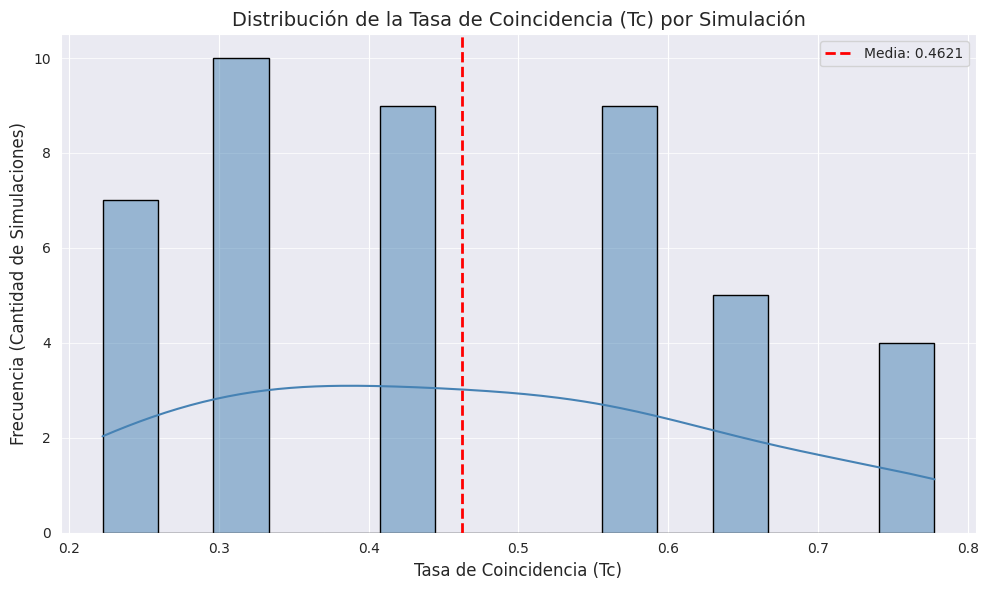

In [10]:
plot_histograma_tc(df_resultados_tc_op4)

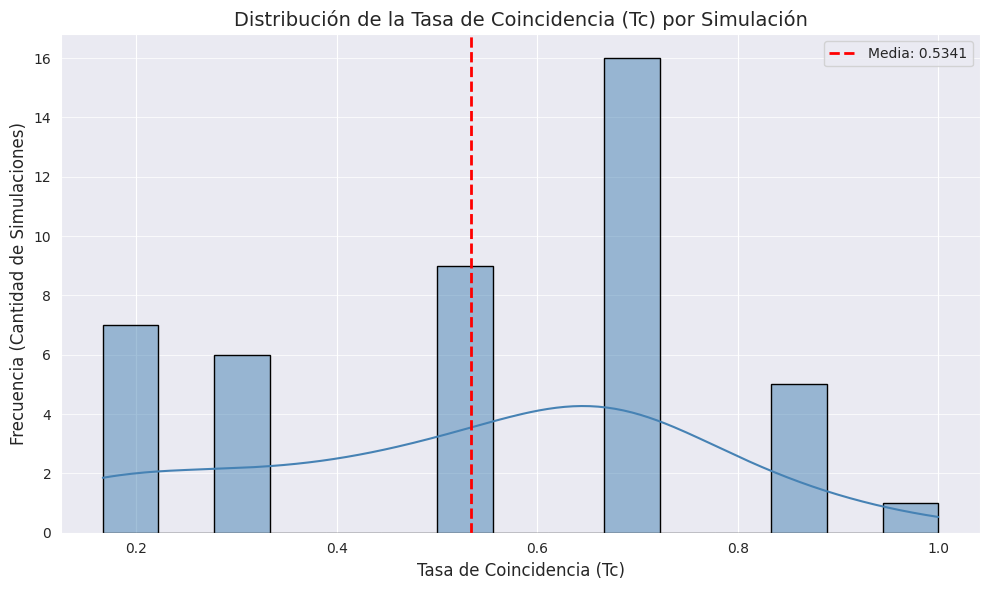

In [11]:
plot_histograma_tc(df_resultados_tc_op2)

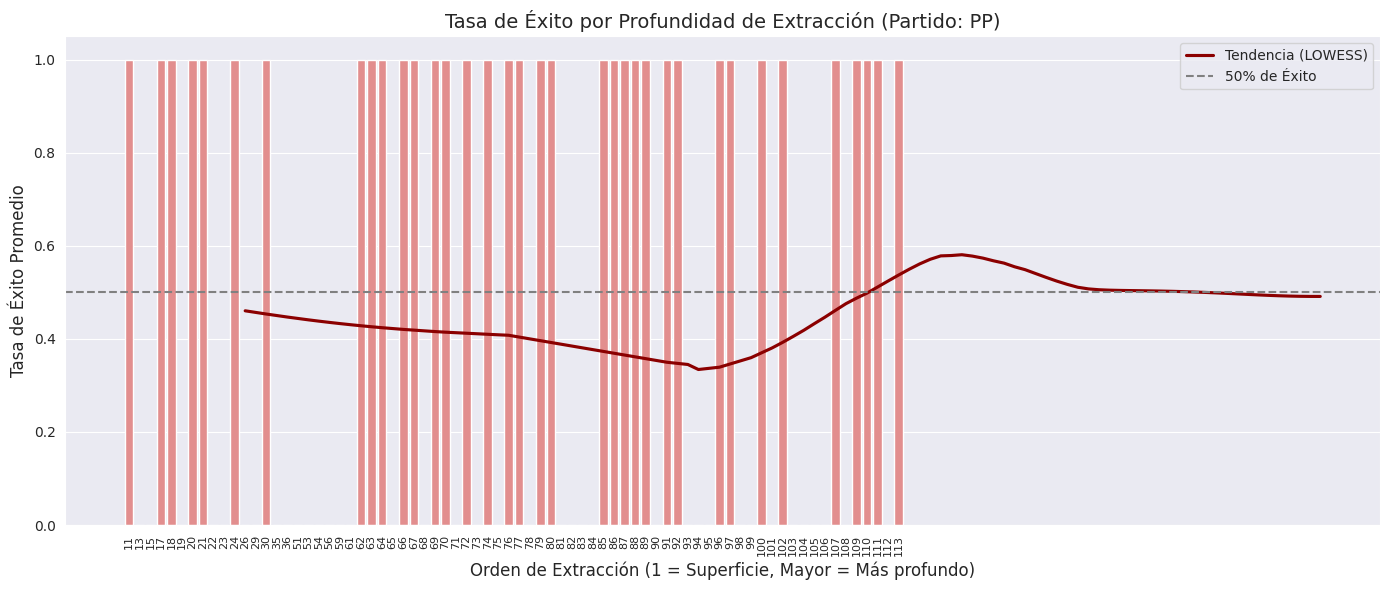

In [10]:
plot_profundidad_error(df_analisis, partido_acronimo='PP', rol_esperado='OPCION 4')

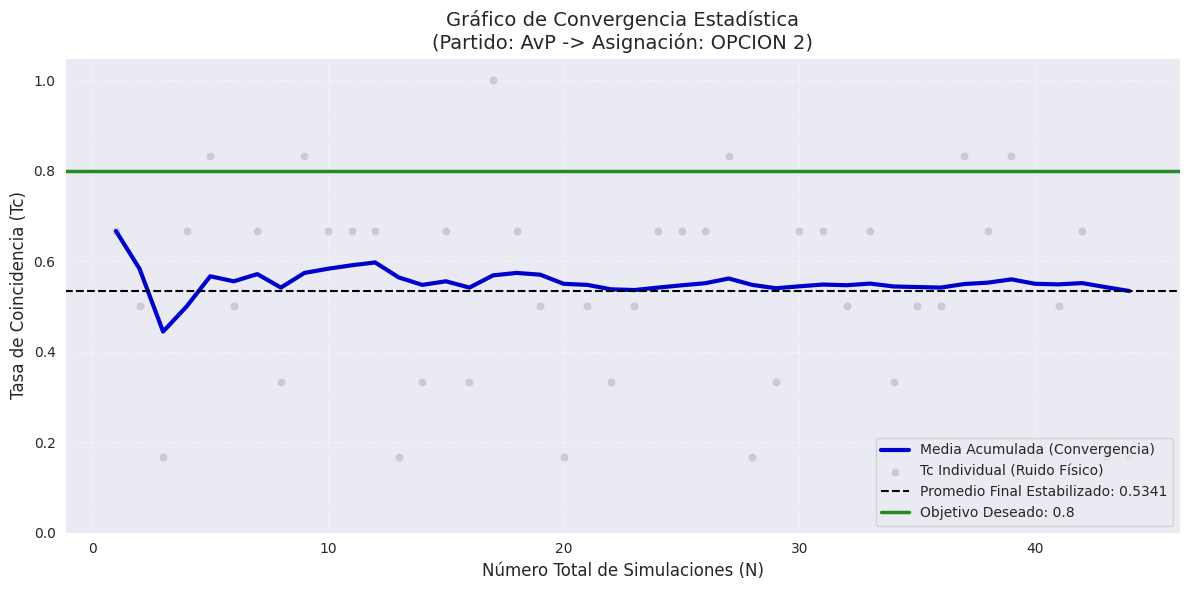

In [12]:
plot_convergencia_tc(df_analisis, partido_acronimo='AvP', rol_esperado='OPCION 2', objetivo_tc=0.80)

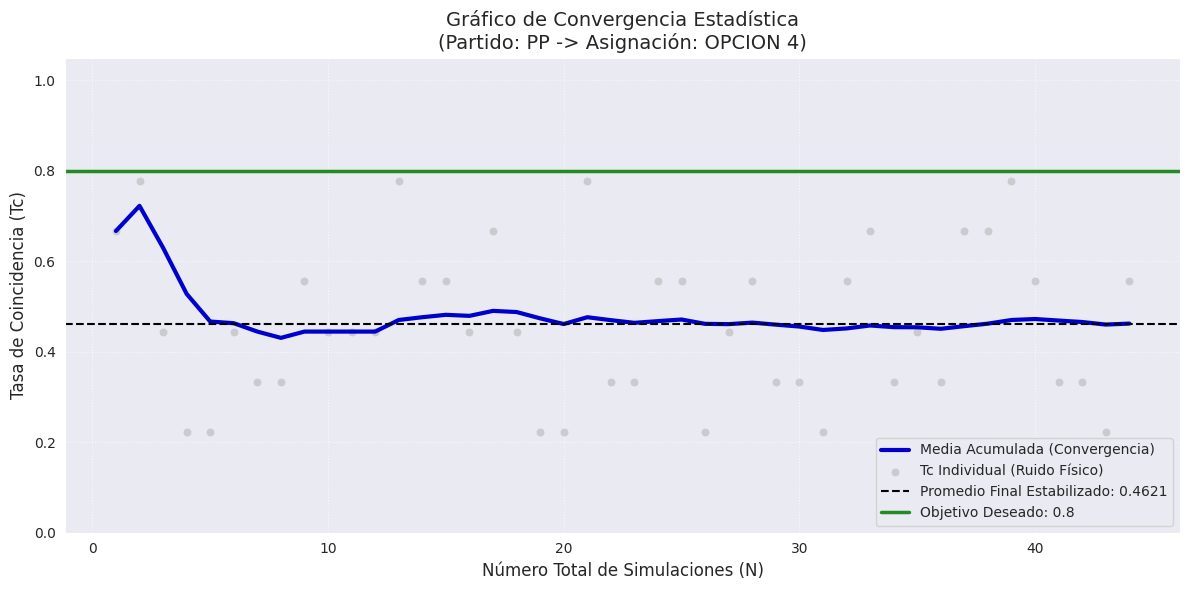

In [13]:
plot_convergencia_tc(df_analisis, partido_acronimo='PP', rol_esperado='OPCION 4', objetivo_tc=0.80)